In [11]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install pandas numpy tqdm matplotlib

Looking in indexes: https://download.pytorch.org/whl/cpu


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self, num_classes=10):
        super(Model, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1) 
        x = self.fc1(x)
        return x


In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Subset
from torchvision import datasets, transforms

seed = 47
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) 
])


train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

subset_size = len(train_dataset) // 10  # 14%
indices = torch.randperm(len(train_dataset))[:subset_size]
train_dataset = Subset(train_dataset, indices)
#train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

original_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 1. Создаем множество всех возможных индексов
all_indices = set(range(len(original_train_dataset)))

# 2. Создаем множество индексов, которые уже вошли в сабсет
subset_indices = set(indices.numpy())

# 3. Находим разницу — индексы, которые не используются
remaining_indices = list(all_indices - subset_indices)

# 4. Выбираем 32 случайных индекса из оставшихся
random_selection_indices = random.sample(remaining_indices, 32)

# 5. Создаем новый сабсет из этих 32 примеров
subset_32 = Subset(original_train_dataset, random_selection_indices)

single_batch = torch.utils.data.DataLoader(subset_32, batch_size=32, shuffle=False)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

Обучение: 100%|██████████| 1875/1875 [00:19<00:00, 98.54it/s] 



Средний лосс за эпоху: 0.07686022458053582


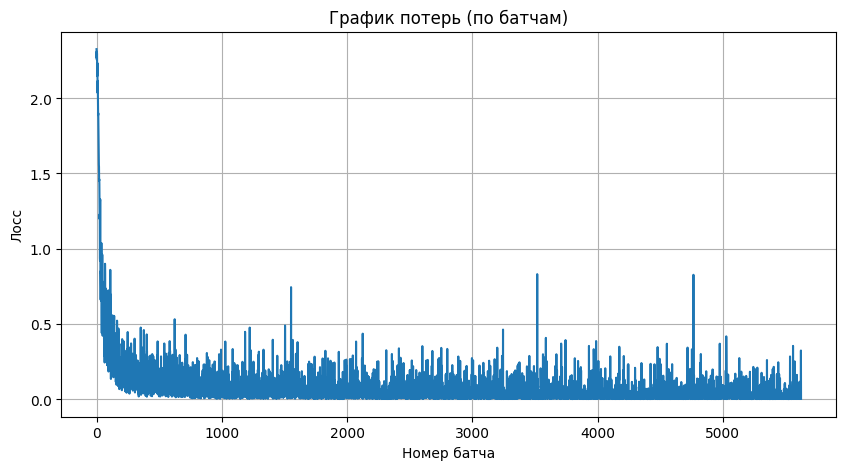

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# model, optimizer, criterion, train_loader, device определены

# 1. Список для хранения лоссов
loss_history = []

for epoch in range(3): 
    model.train()
    for images, labels in tqdm(train_loader, desc="Обучение"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # 2. Сохраняем лосс каждого батча
        loss_history.append(loss.item())

# 3. Создаем DataFrame и выводим график
loss_df = pd.DataFrame({'batch_loss': loss_history})

print("\nСредний лосс за эпоху:", loss_df['batch_loss'].mean())

plt.figure(figsize=(10, 5))
loss_df['batch_loss'].plot(title='График потерь (по батчам)', grid=True)
plt.xlabel("Номер батча")
plt.ylabel("Лосс")
plt.show()

In [16]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)  # Индекс класса с наибольшим логитом
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Точность на тесте: {100 * correct / total:.2f}%")

Точность на тесте: 98.84%


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


from tqdm import tqdm
for epoch in range(250): 
    model.train()
    running_loss = 0.0
    for images, labels in single_batch:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
        
    print(f"Эпоха {epoch}, лосс: {running_loss}")

Эпоха 0, лосс: 2.398345947265625
Эпоха 1, лосс: 2.158367395401001
Эпоха 2, лосс: 1.995501160621643
Эпоха 3, лосс: 1.8795183897018433
Эпоха 4, лосс: 1.7901114225387573
Эпоха 5, лосс: 1.7042698860168457
Эпоха 6, лосс: 1.6079031229019165
Эпоха 7, лосс: 1.4988704919815063
Эпоха 8, лосс: 1.382344365119934
Эпоха 9, лосс: 1.2644795179367065
Эпоха 10, лосс: 1.147571325302124
Эпоха 11, лосс: 1.031913161277771
Эпоха 12, лосс: 0.9188860654830933
Эпоха 13, лосс: 0.8097881078720093
Эпоха 14, лосс: 0.7051228880882263
Эпоха 15, лосс: 0.604986310005188
Эпоха 16, лосс: 0.5110269784927368
Эпоха 17, лосс: 0.4257868826389313
Эпоха 18, лосс: 0.35168638825416565
Эпоха 19, лосс: 0.2893524765968323
Эпоха 20, лосс: 0.23708827793598175
Эпоха 21, лосс: 0.19314467906951904
Эпоха 22, лосс: 0.15649080276489258
Эпоха 23, лосс: 0.12650920450687408
Эпоха 24, лосс: 0.10240554064512253
Эпоха 25, лосс: 0.08295238763093948
Эпоха 26, лосс: 0.06707426905632019
Эпоха 27, лосс: 0.054237667471170425
Эпоха 28, лосс: 0.044145535

Обучение: 100%|██████████| 1875/1875 [00:20<00:00, 93.00it/s]



Средний лосс за эпоху: 0.07496802868729768


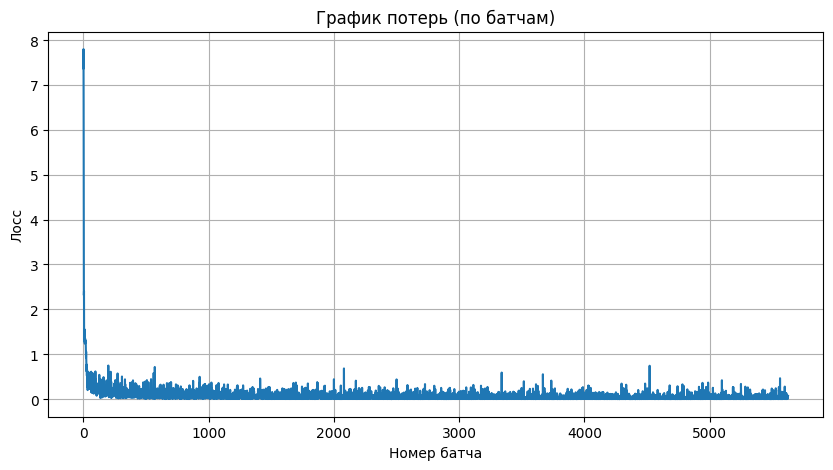

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

loss_history = []

for epoch in range(3): 
    model.train()
    for images, labels in tqdm(train_loader, desc="Обучение"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        loss_history.append(loss.item())

loss_df = pd.DataFrame({'batch_loss': loss_history})

print("\nСредний лосс за эпоху:", loss_df['batch_loss'].mean())

plt.figure(figsize=(10, 5))
loss_df['batch_loss'].plot(title='График потерь (по батчам)', grid=True)
plt.xlabel("Номер батча")
plt.ylabel("Лосс")
plt.show()

In [23]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)  # Индекс класса с наибольшим логитом
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Точность на тесте: {100 * correct / total:.2f}%")

Точность на тесте: 98.80%


In [20]:
Точность на тесте: 98.45%
Точность на тесте: 98.66%

SyntaxError: invalid syntax (3317086631.py, line 1)

In [ ]:
import pandas as pd

# наши данные
seeds = [42, 43, 44, 45]
accuracy = [97.27, 97.34, 97.74, 97.36]
accuracy_sbo = [97.31, 97.54, 97.35, 97.67]

df = pd.DataFrame({
    'seed': seeds,
    'test_accuracy': accuracy,
    'test_accuracy (SBO)': accuracy_sbo
})

df['delta'] = df['test_accuracy (SBO)'] - df['test_accuracy']

df

,seed,test_accuracy,test_accuracy (SBO),delta
0,42,97.27,97.31,0.04
1,43,97.34,97.54,0.20
2,44,97.74,97.35,-0.39
3,45,97.36,97.67,0.31
